# Market Image Prediction — Results

Can market state be encoded as an image and predicted with a CNN, and does the result
survive purged walk-forward validation and trading costs?

This notebook renders the analysis from committed result tables. It needs no data access.
The pipeline that produced them requires WRDS (CRSP + OptionMetrics); see the README.


In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
    'grid.alpha': 0.25, 'axes.spines.top': False, 'axes.spines.right': False,
})
BLUE, RUST, TEAL = '#1C6DD0', '#C2410C', '#00918F'

main = pl.read_csv('../results/main_results.csv')
comp = pl.read_csv('../results/universe_comparison.csv')
dec  = pl.read_csv('../results/decile_profiles.csv')
main.shape


Matplotlib is building the font cache; this may take a moment.


(9, 16)

## 1. Headline

Out-of-fold across 20 rolling-origin folds, 2006–2025. 235 monthly decision dates,
~1,856 US equities per date. Signal-weighted quartile long/short, 21-day holding.


In [2]:
cols = ['model','rank_ic','ic_t','spread_pct','spread_t','turnover',
        'sharpe_10','sharpe_50','alpha_annual','alpha_t','r_squared']
main.select(cols).sort('sharpe_10', descending=True).to_pandas()


,model,rank_ic,ic_t,spread_pct,spread_t,turnover,sharpe_10,sharpe_50,alpha_annual,alpha_t,r_squared
0,surface_cnn,0.02437,3.70,0.9782,4.51,0.565,1.403,1.018,0.1038,6.29,0.097
1,surface_ridge,0.01468,3.35,0.6510,4.33,0.691,1.247,0.554,0.0596,5.52,0.095
2,gbm_tabular,0.02521,4.26,0.8234,3.75,0.679,0.975,0.510,0.0742,4.83,0.081
3,ridge_tabular,0.03237,3.40,1.1323,3.57,0.548,0.903,0.626,0.0855,4.19,0.096
4,logistic_tabular,0.03172,3.40,1.0812,3.51,0.561,0.884,0.589,0.0807,4.10,0.095
5,naive_momentum_60,-0.00013,-0.02,0.3023,1.22,0.490,0.179,-0.100,0.0162,0.77,0.009
6,naive_momentum_20,-0.00532,-0.79,0.1972,0.87,0.806,0.079,-0.413,0.0005,0.03,0.029
7,naive_vol_scaled_momentum,-0.00556,-0.81,0.0662,0.35,0.806,-0.013,-0.681,-0.0086,-0.62,0.034
8,naive_reversal_5,0.00706,0.98,0.0777,0.40,0.808,-0.061,-0.585,0.0010,0.05,0.033


`surface_cnn` reaches **1.40 net Sharpe at 10bps** and holds **1.02 at 50bps** — the
only model that survives heavy costs.

Note it does *not* have the best rank IC. Ridge ranks the whole cross-section better
(0.0324 vs 0.0244) but the surface CNN has the highest **spread t-statistic** (4.51).
It separates the extremes better while ordering the middle worse — and only the
extremes are traded.


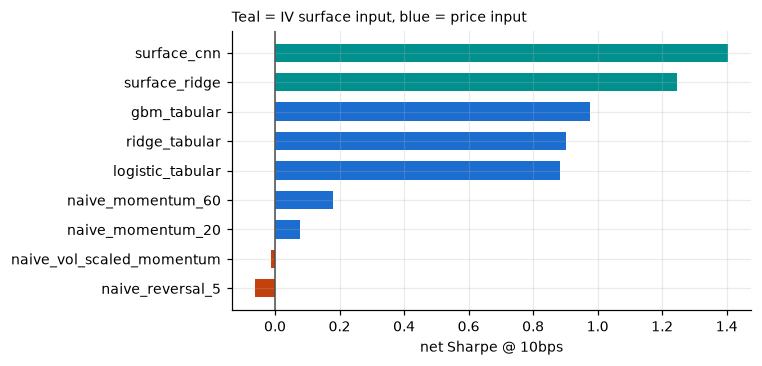

In [3]:
d = main.sort('sharpe_10').to_pandas()
fig, ax = plt.subplots(figsize=(7, 3.4))
colors = [TEAL if m.startswith('surface') else BLUE for m in d.model]
colors = [c if s > 0 else RUST for c, s in zip(colors, d.sharpe_10)]
ax.barh(d.model, d.sharpe_10, color=colors, height=0.62)
ax.axvline(0, color='0.3', lw=1)
ax.set_xlabel('net Sharpe @ 10bps')
ax.set_title('Teal = IV surface input, blue = price input', loc='left', fontsize=9)
plt.tight_layout()


## 2. Metrics, and why they are computed this way

### Rank IC

Spearman correlation between predicted and realised ranks, computed **within a single
date** and averaged across dates. One number per date, 235 dates.

A rank IC of 0.02 sounds negligible and is a normal effect size in equity
cross-section. Breadth converts it into money: the same weak edge applied across
~1,850 names, 12 times a year.

### Why the t-statistics are Newey–West

A 21-day label with monthly decisions makes the IC series autocorrelated by
construction. An ordinary standard error treats correlated observations as independent
and inflates t by roughly √(overlap). Every t here is HAC-corrected.

### Alpha

Intercept of a regression on Fama–French five factors plus momentum, HAC errors. A
long-short book can post a good Sharpe while owning nothing but known risk premia —
shorting small, unprofitable, volatile names has paid for decades.


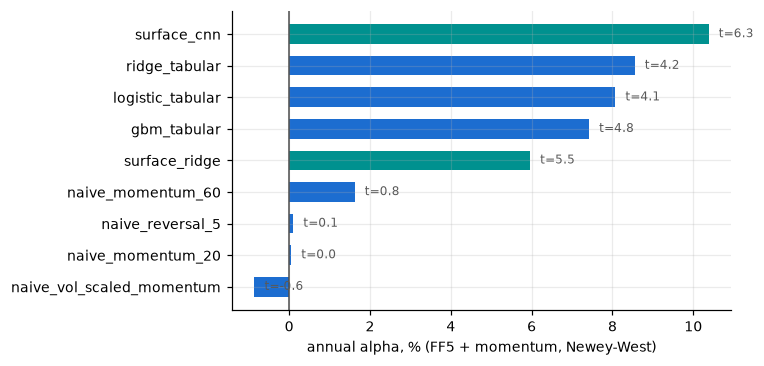

In [4]:
a = main.sort('alpha_annual', descending=True).to_pandas()
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(a.model, a.alpha_annual * 100,
        color=[TEAL if m.startswith('surface') else BLUE for m in a.model], height=0.62)
for y, (v, t) in enumerate(zip(a.alpha_annual*100, a.alpha_t)):
    ax.text(v + 0.25, y, f't={t:.1f}', va='center', fontsize=8, color='0.35')
ax.axvline(0, color='0.3', lw=1)
ax.set_xlabel('annual alpha, % (FF5 + momentum, Newey-West)')
ax.invert_yaxis(); plt.tight_layout()


R² is ~0.10 for every model: the six factors explain almost none of the variance.
The surface CNN's alpha is **+10.4%/yr at t = 6.29**, and factor exposures are a small
*net drag* rather than the source of return.


## 3. Where the signal lives

Rank IC averages over the whole cross-section; the strategy only trades the ends.
Sorting by prediction into deciles and measuring return **in excess of each date's
cross-sectional mean** shows the difference.


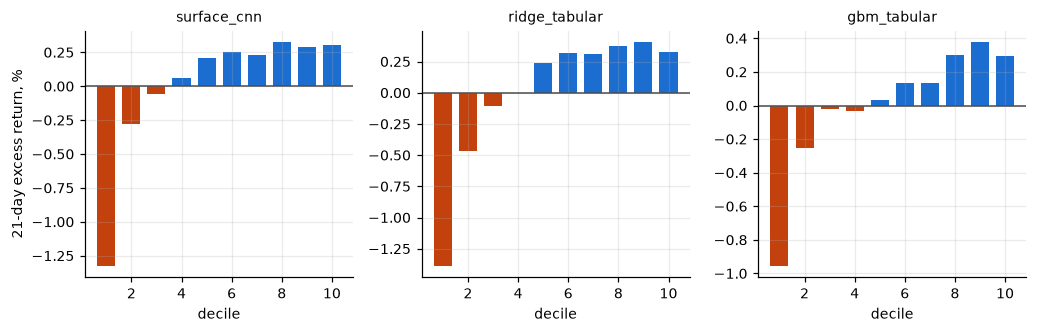

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.1), sharex=True)
for ax, m in zip(axes, ['surface_cnn', 'ridge_tabular', 'gbm_tabular']):
    g = dec.filter(pl.col('model') == m).sort('decile').to_pandas()
    v = g.excess_return * 100
    ax.bar(g.decile, v, color=[BLUE if x >= 0 else RUST for x in v], width=0.72)
    ax.axhline(0, color='0.3', lw=1)
    ax.set_title(m, fontsize=9); ax.set_xlabel('decile')
axes[0].set_ylabel('21-day excess return, %')
plt.tight_layout()


Demeaning within each date matters. Without it every decile is positive, because every
decile inherits the market's move; the asymmetry only appears once that is removed.


## 4. The decisive change: demeaning the surface

Implied volatility varies far more across firms than across one firm's own surface. Fed
raw values, the network found that level and stopped — it ranked stocks by volatility
(ρ = −0.40 with mean IV) and ignored the shape (ρ = −0.02 with skew).

Subtracting each surface's own mean leaves only geometry.

| | rank IC | t | spread | t |
|---|---|---|---|---|
| raw | +0.0038 | 0.31 | +0.489% | 1.34 |
| demeaned | **+0.0185** | **2.34** | **+0.669%** | **2.67** |

Correlation with level fell to zero; with skew it rose sixfold. The level was not
carrying the signal — it was crowding it out.

Scaling is per surface, so it depends on nothing but that sample: no fitted state, no
leakage channel.


## 5. Breadth

The fundamental law of active management says IR ≈ IC × √breadth. At 500 names and
monthly rebalancing the theoretical ceiling was 1.43 and the realised figure 0.71.

Widening to 2,000 names predicted 2.00×.


In [6]:
w = (comp.filter(pl.col('model').is_in(['ridge_tabular','logistic_tabular',
                                        'gbm_tabular','naive_reversal_5']))
         .pivot(on='universe', index='model', values='sharpe_10'))
w = w.with_columns((pl.col('crsp_2000') / pl.col('crsp_500')).round(2).alias('ratio'))
w.to_pandas()


,model,crsp_500,crsp_2000,ratio
0,ridge_tabular,0.521,0.903,1.73
1,gbm_tabular,0.315,0.975,3.10
2,naive_reversal_5,0.139,-0.061,-0.44
3,logistic_tabular,0.463,0.884,1.91


Ridge landed on **1.97×** against a predicted 2.00×.

Two details worth reading. Turnover *fell* (0.687 → 0.562) — quartile boundaries are
more stable in a wider cross-section, so fewer names cross the cut. And reversal went
**backwards**: short-horizon reversal is a small-cap effect, and diluting it across
larger names weakened it. Breadth multiplies a signal that generalises; it is not a
free lever.


## 6. What did not work

Recorded because the failures constrain the conclusions.

**GAF images.** On price data the GAF CNN lost to a 1D convolutional network given
provably identical information — same windows, features, folds and resolution. Rank IC
+0.0078 against +0.0126. Folding a 1-D series into a square costs information rather
than exposing it. That is what motivated moving to a natively 2-D representation.

**Sector specialisation.** Per-sector IC appeared to vary 4.3×. Capping every sector to
the same cross-section width and comparing against *arbitrary* splits of the same data:

| | IC spread (sd) |
|---|---|
| real sectors, capped to 30 names | 0.0193 |
| arbitrary halves, 30 names | 0.0171 |

Ratio 1.13×. The heterogeneity was cross-section width, not sector.

**Regime gating.** IC by dispersion tercile looked strong — but sorted dates by their
*own realised* dispersion, unobservable at the decision date. The tradable version
(prior-month dispersion) collapses from a spread of 0.0184 to 0.0060, beating only 11%
of random date regroupings.

**Signal blending.** Surface and price signals correlate only 0.21 per date (two price
models correlate 0.57). A fixed 50/50 blend gives a better predictor — highest rank IC,
spread and alpha — but a worse strategy: Sharpe 1.21 against 1.40. Equal weighting a
strong signal with a weaker one pulls toward the average.


## 7. Corrections made during the work

**Annualisation.** The rebalance schedule was stepped twice: decision dates arrived
pre-thinned to monthly and the step was applied again. The backtest traded 47 times in
19 years while annualising as 12/year — overstating every Sharpe by **2.2×**. The
factor is now measured from the traded dates and warns when it disagrees with the
holding period.

**Horizon/frequency mismatch.** A 5-day label with monthly rebalancing holds for a week
and sits idle for three. Matching the horizon to the rebalance interval was worth more
than any architecture choice in the project.

**Surface completeness.** The vendor emits a row for every grid point and nulls the
value when it cannot fit one, so a row-count check passes surfaces full of holes.
Completeness is measured on observed values. Separately, the 10-day maturity is 85%
missing; dropping it took completeness from 15% to 99%.

**Checkpoint overlap.** Changing a download chunk from 3 years to 2 made new files
silently overlap old ones — 35% duplicated rows, every file individually valid. Chunk
filenames now carry their whole span and assembly refuses duplicate keys.


## 8. Caveats

- **Flat basis-point costs.** A liquidity-scaled model (cost ∝ 1/√volume) is
  implemented but the headline uses a flat rate, optimistic for smaller names.
- **No market impact, no borrow costs.** Both bite hardest on the short leg, which
  carries most of the spread.
- **235 monthly observations.** Enough for the headline, not enough to resolve
  conditional effects — which the sector and regime tests demonstrate directly.
- **Failure mode is junk rallies.** Worst drawdown −23.0% (Jan-2009 to Mar-2010); worst
  years 2020 and 2009. The `rmw` loading of +0.29 says long profitable / short
  unprofitable, which is destroyed when low-quality names rally off a bottom.
